# Volatility Toolkit Demo

This notebook demonstrates RiskOptima's volatility toolkit: historical volatility, rolling volatility, realized volatility, EWMA volatility, OHLC estimators, and Black-Scholes implied volatility. The data is synthetic and deterministic so the notebook runs without external data.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from riskoptima.options import black_scholes_price
from riskoptima.volatility import (
    ewma_volatility,
    garman_klass_volatility,
    historical_volatility,
    implied_volatility,
    parkinson_volatility,
    realized_volatility,
    rogers_satchell_volatility,
    rolling_volatility,
    yang_zhang_volatility,
)

plt.style.use("seaborn-v0_8-whitegrid")

from riskoptima import RiskOptima
print(RiskOptima.VERSION)

2.4.1


## 1. Create synthetic daily prices

Historical volatility measures how much prices have moved in the past. We generate a daily price path from seeded returns, then compute volatility from both prices and returns.

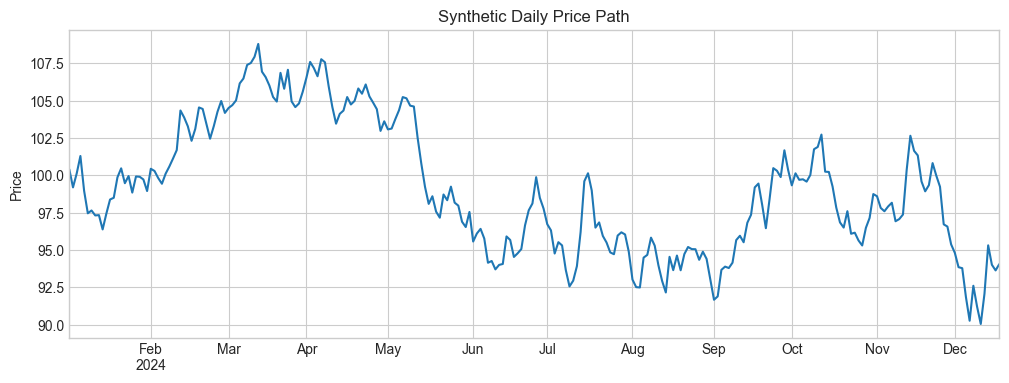

In [6]:
rng = np.random.default_rng(42)
dates = pd.bdate_range("2024-01-02", periods=252)
daily_returns = pd.Series(rng.normal(0.0004, 0.012, len(dates)), index=dates, name="returns")
prices = (1.0 + daily_returns).cumprod() * 100.0

fig, ax = plt.subplots(figsize=(12, 4))
prices.plot(ax=ax, title="Synthetic Daily Price Path")
ax.set_ylabel("Price")
plt.show()

## 2. Historical and rolling volatility

Close-to-close historical volatility is the annualized standard deviation of returns. Rolling volatility shows how the estimate changes through time.

Historical volatility from returns: 17.83%
Historical volatility from prices:  17.86%


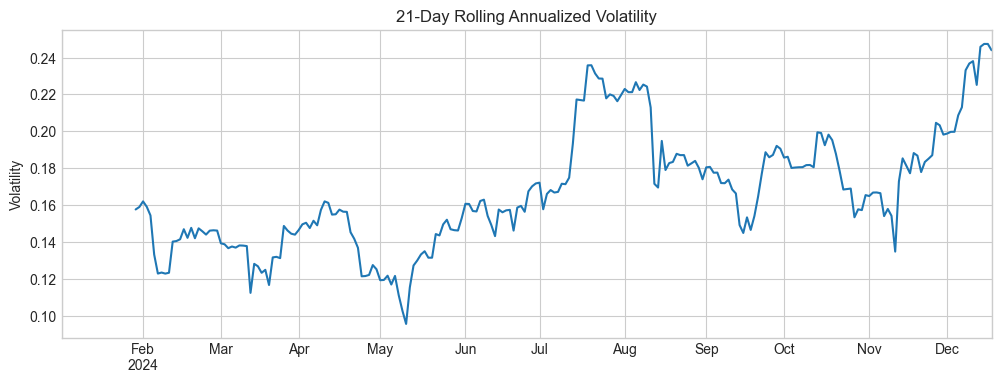

In [8]:
hv_from_returns = historical_volatility(daily_returns, input_type="returns")
hv_from_prices = historical_volatility(prices, input_type="prices")
rv_21d = rolling_volatility(daily_returns, window=21)

print(f"Historical volatility from returns: {hv_from_returns:.2%}")
print(f"Historical volatility from prices:  {hv_from_prices:.2%}")

fig, ax = plt.subplots(figsize=(12, 4))
rv_21d.plot(ax=ax, title="21-Day Rolling Annualized Volatility")
ax.set_ylabel("Volatility")
plt.show()

## 3. Realized and EWMA volatility

Realized volatility uses high-frequency returns over a period. EWMA volatility gives more weight to recent observations, which is useful for risk dashboards.

In [12]:
intraday_prices = pd.Series((1.0 + rng.normal(0.0, 0.0012, 390)).cumprod() * 100.0)
realized = realized_volatility(intraday_prices, input_type="prices")
ewma = ewma_volatility(daily_returns, lambda_=0.94)

print(f"Intraday realized volatility: {realized:.2%}")
print(f"EWMA volatility:              {ewma:.2%}")

Intraday realized volatility: 37.53%
EWMA volatility:              24.63%


## 4. OHLC volatility estimators

OHLC estimators use open, high, low, and close prices. They can extract more information than close-to-close volatility when daily ranges are informative.

In [15]:
open_prices = prices.shift(1).fillna(prices.iloc[0]) * (1.0 + rng.normal(0.0, 0.001, len(prices)))
close_prices = prices
ranges = np.abs(rng.normal(0.006, 0.002, len(prices)))
high_prices = np.maximum(open_prices, close_prices) * (1.0 + ranges)
low_prices = np.minimum(open_prices, close_prices) * (1.0 - ranges)

ohlc = pd.DataFrame({
    "Open": open_prices,
    "High": high_prices,
    "Low": low_prices,
    "Close": close_prices,
}, index=prices.index)

ohlc_vols = pd.Series({
    "Parkinson": parkinson_volatility(ohlc),
    "Garman-Klass": garman_klass_volatility(ohlc),
    "Rogers-Satchell": rogers_satchell_volatility(ohlc),
    "Yang-Zhang": yang_zhang_volatility(ohlc),
})
ohlc_vols.map(lambda x: f"{x:.2%}")

Parkinson          21.49%
Garman-Klass       22.72%
Rogers-Satchell    21.91%
Yang-Zhang         21.46%
dtype: object

## 5. Implied volatility

Implied volatility is the volatility input that makes an option pricing model match the observed market option price. RiskOptima delegates this calculation to the options engine.

In [18]:
S, K, T, r, true_sigma = 100.0, 100.0, 1.0, 0.05, 0.22
market_price = black_scholes_price(S, K, T, r, true_sigma, option_type="call")
iv = implied_volatility(market_price, S, K, T, r, option_type="call")

print(f"Market call price: {market_price:.4f}")
print(f"Recovered implied volatility: {iv:.2%}")

Market call price: 11.2028
Recovered implied volatility: 22.00%


## 6. Compare estimators

Different estimators answer different questions. Historical and EWMA volatility are common for risk monitoring, realized volatility is useful with intraday data, OHLC estimators use daily range information, and implied volatility reflects option market expectations.

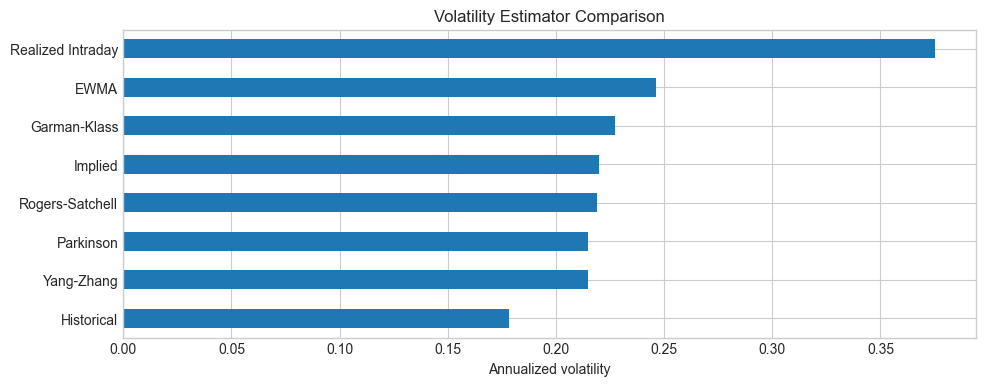

Historical           17.83%
EWMA                 24.63%
Realized Intraday    37.53%
Implied              22.00%
Parkinson            21.49%
Garman-Klass         22.72%
Rogers-Satchell      21.91%
Yang-Zhang           21.46%
dtype: object

In [21]:
comparison = pd.concat([
    pd.Series({
        "Historical": hv_from_returns,
        "EWMA": ewma,
        "Realized Intraday": realized,
        "Implied": iv,
    }),
    ohlc_vols,
])

fig, ax = plt.subplots(figsize=(11, 4))
comparison.sort_values().plot(kind="barh", ax=ax, title="Volatility Estimator Comparison")
ax.set_xlabel("Annualized volatility")
plt.show()
comparison.map(lambda x: f"{x:.2%}")